# Séance 3 : POO Avancée — Structures Algébriques
## Polynômes et Matrices en Python

**M1 MAFI — Université d'Antananarivo — 2026–2027**

---

### Objectifs
- Maîtriser la POO avancée : classes abstraites, héritage, surcharge d'opérateurs.
- Implémenter la classe `Polynome` (anneau $\mathbb{K}[X]$) avec Horner, dérivée, PGCD.
- Implémenter la classe `Matrice` avec élimination de Gauss–Jordan.
- Introduction légère à **Lean 4** : formalisation de propriétés élémentaires.
- Mesurer et comparer les complexités $\mathcal{O}(n)$, $\mathcal{O}(n^2)$, $\mathcal{O}(n^3)$.

---

### Ressources
- Cormen et al., *Introduction to Algorithms*, 4e éd., MIT Press, 2022 — ch. 2 (Horner), ch. 30 (FFT).
- Strang, *Computational Science and Engineering*, Wellesley-Cambridge, 2007 — ch. 1–3 (Gauss).
- Trefethen & Bau, *Numerical Linear Algebra*, SIAM, 1997 — Lecture 20.
- Avigad et al., *Mathematics in Lean*, https://leanprover-community.github.io/mathematics_in_lean/ — §8.

---
**Rappel** : l'usage des assistants IA est autorisé pour déboguer, mais vous devez comprendre et documenter chaque ligne de code.

## Partie 0 — Environnement

In [1]:
import timeit
import random
import math
import copy
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

%matplotlib inline
print("Environnement prêt.")

Environnement prêt.


---
## Partie 1 — POO Avancée : Interface Algébrique

### 1.1 Classe abstraite `StructureAlgebrique`

Une **classe abstraite** (module `abc`) définit une interface que toute sous-classe doit respecter.  
Ici, on modélise un **anneau** : addition, multiplication, et élément neutre nul.

> **Référence** : Python docs, `abc` — https://docs.python.org/3/library/abc.html

In [3]:
class StructureAlgebrique(ABC):
    """Interface abstraite d'un anneau (addition + multiplication)."""

    @abstractmethod
    def __add__(self, other):
        """Addition dans la structure."""
        pass

    @abstractmethod
    def __mul__(self, other):
        """Multiplication dans la structure."""
        pass

    @property
    @abstractmethod
    def zero(self):
        """Élément neutre pour l'addition."""
        pass

    @abstractmethod
    def __eq__(self, other):
        pass

    def __ne__(self, other):
        return not self.__eq__(other)

# Test : on ne peut pas instancier une classe abstraite
try:
    s = StructureAlgebrique()
except TypeError as e:
    print(f"Erreur attendue : {e}")

Erreur attendue : Can't instantiate abstract class StructureAlgebrique without an implementation for abstract methods '__add__', '__eq__', '__mul__', 'zero'


### 1.2 Exemple : héritage et polymorphisme

**Exercice guidé** : compléter la classe `Entier` ci-dessous qui hérite de `StructureAlgebrique`.  
Elle sert d'illustration avant d'implémenter `Polynome`.

In [4]:
class Entier(StructureAlgebrique):
    """Entier comme anneau (illustration du polymorphisme)."""

    def __init__(self, valeur):
        self.val = int(valeur)

    def __add__(self, other):
        return Entier(self.val + other.val)
        raise NotImplementedError

    def __mul__(self, other):
        return Entier(self.val * other.val)
        raise NotImplementedError

    @property
    def zero(self):
        return Entier(0)

    def __eq__(self, other):
        if isinstance(other, Entier):
            return self.val == other.val
        return self.val == other

    def __repr__(self):
        return f"Entier({self.val})"

# Tests automatiques (décommentez après implémentation)
a, b = Entier(3), Entier(5)
assert (a + b) == Entier(8), "Addition incorrecte"
assert (a * b) == Entier(15), "Multiplication incorrecte"
print("Tests Entier OK")

Tests Entier OK


---
## Partie 2 — Classe `Polynome`

Un polynôme $P = a_0 + a_1 X + \cdots + a_n X^n \in \mathbb{K}[X]$ est représenté par la liste  
`coeffs = [a_0, a_1, ..., a_n]` (degré croissant), avec $a_n \neq 0$.

### 2.1 Initialisation et affichage

In [ ]:
class Polynome(StructureAlgebrique):
    """
    Représentation d'un polynôme à coefficients réels.
    coeffs[i] est le coefficient de X^i.
    """

    def __init__(self, coeffs):
        """coeffs : liste/tuple de coefficients (degré croissant)."""
        self.coeffs = list(coeffs)
        self._normaliser()

    def _normaliser(self):
        """Supprime les zéros dominants."""
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()
    def __add__(self, other):
        return super().__add__(other)
    def __mul__(self, other):
        return super().__mul__(other)
    @property
    def degre(self):
        """Degré du polynôme (-1 pour le polynôme nul)."""
        if self.coeffs == [0]:
            return -1
        return len(self.coeffs) - 1

    @property
    def zero(self):
        return Polynome([0])

    def __getitem__(self, i):
        """Coefficient de X^i."""
        return self.coeffs[i] if 0 <= i < len(self.coeffs) else 0

    def __eq__(self, other):
        if isinstance(other, (int, float)):
            return self.coeffs == [other]
        if isinstance(other, Polynome):
            return self.coeffs == other.coeffs
        return NotImplemented

    def __repr__(self):
        return f"Polynome({self.coeffs})"

    def __str__(self):
        if self.degre == -1:
            return "0"
        termes = []
        for i, c in enumerate(self.coeffs):
            if c == 0:
                continue
            if i == 0:
                termes.append(str(c))
            elif i == 1:
                termes.append(f"({c})*X" if c != 1 else "X")
            else:
                termes.append(f"({c})*X^{i}" if c != 1 else f"X^{i}")
        return " + ".join(reversed(termes)) if termes else "0"

    
    def __call__(self, x):
        """Permet d'écrire P(x) directement."""
        return self.evaluer(x)

# Test rapide
P = Polynome([1, -2, 0, 3])   # 1 - 2X + 3X^3
print(f"P = {P}")
print(f"deg(P) = {P.degre}")
print(f"P[0] = {P[0]}, P[3] = {P[3]}")

P = (3)*X^3 + (-2)*X + 1
deg(P) = 3
P[0] = 1, P[3] = 3


### 2.2 Opérations arithmétiques (à compléter)

**Rappel mathématique** :
$$P + Q = \sum_{k=0}^{\max(m,n)} (a_k + b_k) X^k \qquad P \cdot Q = \sum_{k=0}^{m+n}\left(\sum_{i+j=k} a_i b_j\right) X^k$$

In [9]:
def polynome_add(self, other):
    """
    Addition de deux polynômes.
    Complexité : O(max(deg P, deg Q)).
    """
    # TODO : calculer n = max longueur des deux listes de coefficients
    # Indice : utiliser self[i] + other[i] pour i in range(n)
    n = max(len(self.coeffs) , len(other.coeffs) )
    new_coeffs = []
    for i in range(n):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 + c2)
    return Polynome(new_coeffs)   
    raise NotImplementedError

def polynome_neg(self):
    """Opposé d'un polynôme."""
    return Polynome([-c for c in self.coeffs])

def polynome_sub(self, other):
    """Soustraction : P - Q = P + (-Q)."""
    return self.__add__(other.__neg__())

def polynome_mul(self, other):
    """
    Multiplication naïve de deux polynômes.
    Complexité : O(deg(P) * deg(Q)).
    """
    if isinstance(other, (int, float)):
        return Polynome([c * other for c in self.coeffs])
    if not isinstance(other, Polynome):
        return NotImplemented
    # initialiser un tableau resultat de taille deg(P)+deg(Q)+1
    n = len(self.coeffs)
    m = len(other.coeffs)
    result = [0] * (max(1, n + m - 1))
    # accumuler les produits a_i * b_j dans result[i+j]
    for i, a in enumerate(self.coeffs):
        if a == 0:
            continue
        for j, b in enumerate(other.coeffs):
            result[i + j] += a * b
    return Polynome(result)

def polynome_rmul(self, scalaire):
    return self.__mul__(scalaire)

def polynome_pow(self, n):
    """
    Exponentiation rapide (squaring).
    Complexité : O(deg(P)^2 * log n).
    """
    if not isinstance(n, int):
        raise TypeError("Exponent must be integer")
    if n < 0:
        raise ValueError("Exponent must be non-negative")
    if n == 0:
        return Polynome([1])
    result = Polynome([1])
    base = Polynome(self.coeffs[:])
    while n:
        if n & 1:
            result = result * base
        base = base * base
        n >>= 1
    return result

# Injection des méthodes dans la classe
Polynome.__add__  = polynome_add
Polynome.__neg__  = polynome_neg
Polynome.__sub__  = polynome_sub
Polynome.__mul__  = polynome_mul
Polynome.__rmul__ = polynome_rmul
Polynome.__pow__  = polynome_pow

# Tests automatiques (décommentez après implémentation)
P = Polynome([1, 2, 1])  # (X+1)^2
Q = Polynome([1, 1])     # X+1
assert P + Q == Polynome([2, 3, 1]), f"Addition : {P + Q}"
assert P * Q == Polynome([1, 3, 3, 1]), f"Multiplication : {P * Q}"
assert Q ** 2 == P, f"Puissance : {Q**2}"
print("Tests opérations OK")

Tests opérations OK


### 2.3 Évaluation : méthode de Horner (à compléter)

**Algorithme de Horner (1819)** — évaluation en $\mathcal{O}(n)$ :
$$P(x) = a_0 + x\bigl(a_1 + x(a_2 + \cdots + x(a_{n-1} + x \cdot a_n)\cdots)\bigr)$$

> Référence : Knuth, *TAOCP* vol. 2, §4.6.4.

In [ ]:
def polynome_evaluer(self, x):
    """
    Évalue P(x) par la méthode de Horner.
    Complexité : O(n) où n = deg(P).

    Algorithme :
        resultat = 0
        Parcourir les coefficients de a_n à a_0 :
            resultat = resultat * x + coeff
        Retourner resultat
    """
    # Horner : on parcourt les coefficients du plus élevé au plus bas
    # et on accumule le résultat avec une seule multiplication par x
    resultat = 0
    for coeff in reversed(self.coeffs):
        resultat = resultat * x + coeff
    
    return resultat

    

def polynome_evaluer_naif(self, x):
    """
    Évalue P(x) terme à terme (méthode naïve).
    Complexité : O(n^2) — calcule x^i pour chaque i.
    """
    return sum(self.coeffs[i] * (x ** i) for i in range(len(self.coeffs)))

Polynome.evaluer       = polynome_evaluer
Polynome.evaluer_naif  = polynome_evaluer_naif

# Tests
P = Polynome([-5, 1, -2, 3])  # 3X^3 - 2X^2 + X - 5
assert P.evaluer(2) == 13, f"Horner : {P.evaluer(2)}"
assert P.evaluer_naif(2) == 13, f"Naïf : {P.evaluer_naif(2)}"
print(f"P(2) = {P.evaluer(2)}  (attendu : 13)")

P(2) = 13  (attendu : 13)


### 2.4 Dérivée formelle (à compléter)

Si $P = \sum_{i=0}^{n} a_i X^i$, alors $P' = \sum_{i=1}^{n} i \cdot a_i X^{i-1}$.

In [13]:
def polynome_derivee(self):
    """
    Dérivée formelle de P.
    Complexité : O(n).
    """
    if self.degre <= 0:
        return Polynome([0])
    # coefficients de la dérivée : i * a_i pour i >= 1
    derived_coeffs = [i * self.coeffs[i] for i in range(1, len(self.coeffs))]
    return Polynome(derived_coeffs)

def polynome_integrer(self, constante=0):
    """
    Primitive de P avec constante d'intégration.
    Si P = sum a_i X^i, alors intégrale = constante + sum (a_i/(i+1)) X^{i+1}.
    Complexité : O(n).
    """
    integrated = [constante] + [self.coeffs[i] / (i + 1) for i in range(len(self.coeffs))]
    return Polynome(integrated)

Polynome.derivee  = polynome_derivee
Polynome.integrer = polynome_integrer

# Tests
P = Polynome([0, 0, 1])   # X^2
assert P.derivee() == Polynome([0, 2]), f"Dérivée : {P.derivee()}"  # 2X
assert P.integrer() == Polynome([0, 0, 0, 1/3]), f"Intégrale : {P.integrer()}"
print("Tests dérivée/intégrale OK")

Tests dérivée/intégrale OK


### 2.5 Division euclidienne et PGCD (à compléter)

**Théorème** : pour tout $A, B \in \mathbb{K}[X]$ avec $B \neq 0$, il existe $(Q, R)$ unique tel que  
$A = BQ + R$ et $\deg(R) < \deg(B)$.

L'**algorithme d'Euclide** pour les polynômes est identique à celui des entiers.

In [14]:
def polynome_division(self, diviseur):
    """
    Division euclidienne : retourne (Q, R) tels que self = diviseur*Q + R.
    Algorithme : division longue, similaire à la division de grands entiers.
    Complexité : O(deg(self) * deg(diviseur)).
    """
    if diviseur == Polynome([0]):
        raise ZeroDivisionError("Division par le polynôme nul")
    dividende = Polynome(self.coeffs[:])
    quotient  = Polynome([0])
    while dividende.degre >= diviseur.degre:
        deg_diff = dividende.degre - diviseur.degre
        coeff    = dividende.coeffs[-1] / diviseur.coeffs[-1]
        monome   = Polynome([0] * deg_diff + [coeff])
        quotient  = quotient + monome
        dividende = dividende - (monome * diviseur)
    return quotient, dividende


def polynome_pgcd(A, B):
    """
    PGCD de A et B par l'algorithme d'Euclide.
    Retourne un représentant normalisé (coefficient dominant = 1).
    Complexité : O(n^2) où n = max(deg A, deg B).

    Terminaison : le degré du reste décroît strictement à chaque étape.
    """
    # Cas triviaux
    if A == Polynome([0]) and B == Polynome([0]):
        return Polynome([0])
    # Boucle d'Euclide : remplacer (A,B) par (B, A % B) jusqu'à ce que B = 0
    while B != Polynome([0]):
        _, r = A.division_euclidienne(B)
        A, B = B, r
    # Normaliser : rendre le coefficient dominant égal à 1 (si A != 0)
    if A == Polynome([0]):
        return Polynome([0])
    lc = A.coeffs[-1]
    normalized = Polynome([c / lc for c in A.coeffs])
    return normalized

Polynome.division_euclidienne = polynome_division
Polynome.pgcd = staticmethod(polynome_pgcd)

# Tests
A = Polynome([-1, 0, 0, 1])   # X^3 - 1
B = Polynome([-1, 0, 1])       # X^2 - 1
G = Polynome.pgcd(A, B)
print(f"pgcd(X^3-1, X^2-1) = {G}")  # attendu : X - 1
Q, R = A.division_euclidienne(B)
print(f"Vérification : B*Q + R = {B*Q + R}")  # doit égaler A

pgcd(X^3-1, X^2-1) = X + -1.0
Vérification : B*Q + R = X^3 + -1


---
## Partie 3 — Classe `Matrice`

> Référence principale : Strang, *CSE*, ch. 1–3 ; Trefethen & Bau, Lectures 20–23.

### 3.1 Initialisation et affichage

In [15]:
class Matrice:
    """
    Matrice m×n de réels, stockée en liste de listes (lignes).
    """

    def __init__(self, lignes):
        self.data = [list(lig) for lig in lignes]
        self.m = len(self.data)
        self.n = len(self.data[0]) if self.data else 0

    @classmethod
    def nulle(cls, m, n):
        """Matrice nulle m×n."""
        return cls([[0.0] * n for _ in range(m)])

    @classmethod
    def identite(cls, n):
        """Matrice identité n×n."""
        M = cls.nulle(n, n)
        for i in range(n):
            M.data[i][i] = 1.0
        return M

    @classmethod
    def aleatoire(cls, m, n, entiers=False, borne=10):
        """Matrice aléatoire m×n."""
        if entiers:
            return cls([[random.randint(-borne, borne) for _ in range(n)]
                        for _ in range(m)])
        return cls([[random.uniform(-borne, borne) for _ in range(n)]
                    for _ in range(m)])

    def __getitem__(self, idx):
        i, j = idx
        return self.data[i][j]

    def __setitem__(self, idx, val):
        i, j = idx
        self.data[i][j] = val

    def __repr__(self):
        return f"Matrice({self.data})"

    def __str__(self):
        larg = max(len(f"{self.data[i][j]:.3g}")
                   for i in range(self.m) for j in range(self.n))
        rows = ["  ".join(f"{x:{larg}.3g}" for x in ligne)
                for ligne in self.data]
        return "\n".join(f"| {r} |" for r in rows)

# Exemple
A = Matrice([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(A)
print(f"\nDimensions : {A.m} x {A.n}")

| 1  2  3 |
| 4  5  6 |
| 7  8  9 |

Dimensions : 3 x 3


### 3.2 Opérations arithmétiques (à compléter)

| Opération | Complexité |
|-----------|------------|
| Addition $A + B$ | $\mathcal{O}(mn)$ |
| Transposée $A^T$ | $\mathcal{O}(mn)$ |
| Multiplication $A \cdot B$ | $\mathcal{O}(mnp)$ — naïf |

In [16]:
def matrice_add(self, other):
    """
    Addition terme à terme. Complexité : O(m*n).
    Précondition : self et other ont les mêmes dimensions.
    """
    assert self.m == other.m and self.n == other.n, "Dimensions incompatibles"
    # Créer une nouvelle matrice résultat
    # Pour chaque ligne i et chaque colonne j : additionner les éléments
    resultat = []
    for i in range(self.m):
        nouvelle_ligne = []
        for j in range(self.n):
            nouvelle_ligne.append(self.data[i][j] + other.data[i][j])
        resultat.append(nouvelle_ligne)
    return Matrice(resultat)

def matrice_neg(self):
    return Matrice([[-x for x in lig] for lig in self.data])

def matrice_sub(self, other):
    return self.__add__(other.__neg__())

def matrice_mul(self, other):
    """
    Multiplication matricielle naïve. Complexité : O(m * n * p).
    Précondition : self est m×n, other est n×p.

    C[i][j] = sum_{k=0}^{n-1} A[i][k] * B[k][j]
    """
    if isinstance(other, (int, float)):
        return Matrice([[other * x for x in lig] for lig in self.data])
    assert self.n == other.m, f"Dimensions : ({self.m},{self.n}) x ({other.m},{other.n})"
    
    # Construire la matrice résultat C de dimensions m×p
    # self est m×n, other est n×p, donc C est m×p
    m = self.m          # nombre de lignes de self
    n = self.n          # nombre de colonnes de self = nombre de lignes de other
    p = other.n         # nombre de colonnes de other
    
    # Initialiser la matrice résultat avec des zéros
    C = [[0.0] * p for _ in range(m)]
    
    # Triple boucle : pour chaque élément C[i][j]
    for i in range(m):
        for j in range(p):
            # Calculer le produit scalaire de la ligne i de self avec la colonne j de other
            for k in range(n):
                C[i][j] += self.data[i][k] * other.data[k][j]
    
    return Matrice(C)

def matrice_transposee(self):
    """
    Transposée : (A^T)[i][j] = A[j][i]. Complexité : O(m*n).
    """
    # Créer une nouvelle matrice de dimensions n×m (inversées)
    # Pour chaque position [i][j] de la transposée, prendre A[j][i]
    result = []
    for j in range(self.n):
        nouvelle_ligne = []
        for i in range(self.m):
            nouvelle_ligne.append(self.data[i][j])
        result.append(nouvelle_ligne)
    return Matrice(result)

def matrice_trace(self):
    """Trace (matrice carrée). Complexité : O(n)."""
    assert self.m == self.n, "La trace nécessite une matrice carrée"
    return sum(self.data[i][i] for i in range(self.n))

def matrice_eq(self, other):
    if not isinstance(other, Matrice):
        return NotImplemented
    return self.data == other.data

Matrice.__add__       = matrice_add
Matrice.__neg__       = matrice_neg
Matrice.__sub__       = matrice_sub
Matrice.__mul__       = matrice_mul
Matrice.transposee    = matrice_transposee
Matrice.trace         = matrice_trace
Matrice.__eq__        = matrice_eq

# Tests
A = Matrice([[1, 2], [3, 4]])
B = Matrice([[5, 6], [7, 8]])
print("A + B ="); print(A + B)
print("A * B ="); print(A * B)   # [[19,22],[43,50]]
print("A^T  ="); print(A.transposee())
print(f"tr(A) = {A.trace()}")    # 5

A + B =
|  6   8 |
| 10  12 |
A * B =
| 19  22 |
| 43  50 |
A^T  =
| 1  3 |
| 2  4 |
tr(A) = 5


### 3.3 Élimination de Gauss–Jordan avec pivot partiel (à compléter)

**Algorithme** (Strang, CSE, ch. 1) :
1. Pour chaque colonne pivot : choisir la ligne avec le plus grand $|a_{ij}|$ (*pivot partiel*).
2. Normaliser la ligne pivot (diviser par le pivot).
3. Éliminer dans **toutes** les autres lignes (forme réduite RREF).

**Complexité** : $\mathcal{O}(n^3)$.

In [17]:
def matrice_gauss_jordan(self, b=None):
    """
    Élimination de Gauss–Jordan avec pivot partiel.

    - Si b est fourni (liste de n réels) : résout Ax = b et retourne x.
    - Sinon : retourne la forme échelonnée réduite (RREF) de A.

    Complexité : O(n^3).
    Référence : Trefethen & Bau, Numerical Linear Algebra, Lecture 20.
    """
    n = self.m
    # Construction de la matrice augmentée [A | b] ou copie de A
    if b is not None:
        M = [self.data[i][:] + [float(b[i])] for i in range(n)]
        ncols = n + 1
    else:
        M = [lig[:] for lig in self.data]
        ncols = self.n

    pivot_col = 0
    for pivot_row in range(n):
        if pivot_col >= ncols:
            break
        # Pivot partiel
        max_row = max(range(pivot_row, n), key=lambda r: abs(M[r][pivot_col]))
        if abs(M[max_row][pivot_col]) < 1e-12:
            pivot_col += 1
            continue
        M[pivot_row], M[max_row] = M[max_row], M[pivot_row]
        
        # 1. Normaliser la ligne pivot_row (diviser par le pivot)
        pivot_value = M[pivot_row][pivot_col]
        for j in range(ncols):
            M[pivot_row][j] /= pivot_value
        
        # 2. Pour chaque ligne i != pivot_row, éliminer la colonne pivot_col
        for i in range(n):
            if i != pivot_row:
                factor = M[i][pivot_col]
                for j in range(ncols):
                    M[i][j] -= factor * M[pivot_row][j]
        
        pivot_col += 1

    if b is not None:
        return [M[i][-1] for i in range(n)]
    return Matrice([lig[:self.n] for lig in M])

Matrice.gauss_jordan = matrice_gauss_jordan

# Tests (décommentez après implémentation)
A = Matrice([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]])
b = [8, -11, -3]
x = A.gauss_jordan(b)
print(f"Solution : {[round(xi, 6) for xi in x]}")  # [2.0, 3.0, -1.0]
# Vérification : Ax doit donner b
Ax = [sum(A[i,j]*x[j] for j in range(3)) for i in range(3)]
print(f"Vérification Ax = {[round(v,6) for v in Ax]}")  # [8, -11, -3]

Solution : [2.0, 3.0, -1.0]
Vérification Ax = [8.0, -11.0, -3.0]


### 3.4 Déterminant (à compléter)

Le déterminant se calcule en $\mathcal{O}(n^3)$ par l'élimination de Gauss :  
$\det(A) = \prod_i u_{ii}$ (produit des pivots), avec signe $-1$ par échange de lignes.

In [18]:
def matrice_determinant(self):
    """
    Déterminant par élimination de Gauss avec pivot partiel.
    Complexité : O(n^3).

    Principe : det(A) = (+/-1) * produit des pivots,
    avec signe -1 pour chaque échange de lignes.
    """
    assert self.m == self.n, "Le déterminant est défini pour les matrices carrées"
    n = self.m
    M   = [lig[:] for lig in self.data]
    det = 1.0
    
    for col in range(n):
        # 1. Trouver la ligne avec le plus grand |M[r][col]| pour r >= col
        max_row = max(range(col, n), key=lambda r: abs(M[r][col]))
        
        # 2. Si ce maximum est < 1e-12 : retourner 0.0 (matrice singulière)
        if abs(M[max_row][col]) < 1e-12:
            return 0.0
        
        # 3. Échanger les lignes si nécessaire et multiplier det par -1
        if max_row != col:
            M[col], M[max_row] = M[max_row], M[col]
            det *= -1.0
        
        # 4. Mettre à jour det *= M[col][col]
        det *= M[col][col]
        
        # 5. Éliminer en dessous (rendre les éléments sous la diagonale = 0)
        for i in range(col + 1, n):
            if abs(M[col][col]) > 1e-12:
                factor = M[i][col] / M[col][col]
                for j in range(col, n):
                    M[i][j] -= factor * M[col][j]
    
    return det

Matrice.determinant = matrice_determinant

# Tests
print(Matrice([[1,2],[3,4]]).determinant())         # -2
print(Matrice([[2,1,-1],[-3,-1,2],[-2,1,2]]).determinant())  # -1
print(Matrice.identite(4).determinant())             # 1

-2.0
-0.9999999999999993
1.0


---
## Partie 4 — Introduction à Lean 4

> **Référence** : Avigad et al., *Mathematics in Lean*, §8 — Polynomials and Power Series.  
> Installer Lean 4 + Mathlib : https://leanprover-community.github.io/get_started.html

Cette partie est à réaliser **dans VS Code avec l'extension Lean 4**, pas dans Jupyter.  
Copiez le code ci-dessous dans un fichier `seance3.lean` et observez les résultats dans l'InfoView.

### Concepts clés de Lean 4 pour les polynômes

Dans **Mathlib**, les polynômes à coefficients dans un anneau `R` sont le type `Polynomial R`.  
L'évaluation en `x : R` est `Polynomial.eval x P`.

```lean
-- Fichier : seance3.lean
-- Importer Mathlib (après avoir configuré votre projet Lean)
import Mathlib.RingTheory.Polynomial.Basic
import Mathlib.Data.Polynomial.Degree.Definitions
import Mathlib.Data.Polynomial.Eval

open Polynomial

-- ───────────────────────────────────────────────────────────────
-- Lemme 1 : L'évaluation est un homomorphisme d'anneaux
-- (P + Q)(x) = P(x) + Q(x)
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) (x : ℝ) :
    (P + Q).eval x = P.eval x + Q.eval x := by
  simp [eval_add]

-- ───────────────────────────────────────────────────────────────
-- Lemme 2 : Commutativité de l'addition dans ℝ[X]
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) : P + Q = Q + P := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Lemme 3 : deg(P + Q) ≤ max(deg P, deg Q)
-- (Ce résultat est natDegree_add_le dans Mathlib)
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) :
    (P + Q).natDegree ≤ max P.natDegree Q.natDegree :=
  natDegree_add_le P Q

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.1 : Montrer que (X + 1)² = X² + 2X + 1
-- ───────────────────────────────────────────────────────────────
example : (X + 1 : Polynomial ℤ) ^ 2 = X ^ 2 + 2 * X + 1 := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.2 : X³ - 1 = (X - 1)(X² + X + 1)
-- ───────────────────────────────────────────────────────────────
example : (X ^ 3 - 1 : Polynomial ℤ) =
          (X - 1) * (X ^ 2 + X + 1) := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.3 (ouvert) : Montrer que si P(a) = 0,
-- alors (X - a) divise P dans ℝ[X].
-- Chercher : Polynomial.dvd_iff_isRoot dans Mathlib
-- ───────────────────────────────────────────────────────────────
#check Polynomial.dvd_iff_isRoot
```

---
## Partie 5 — Analyse de Complexité Empirique

### 5.1 Horner vs évaluation naïve

deg= 100 | Horner: 17.18 µs | Naïf: 55.96 µs
deg= 300 | Horner: 24.90 µs | Naïf: 127.10 µs
deg= 600 | Horner: 49.06 µs | Naïf: 529.40 µs
deg=1000 | Horner: 191.64 µs | Naïf: 523.24 µs
deg=2000 | Horner: 286.92 µs | Naïf: 1209.94 µs
deg=3000 | Horner: 441.58 µs | Naïf: 1496.60 µs


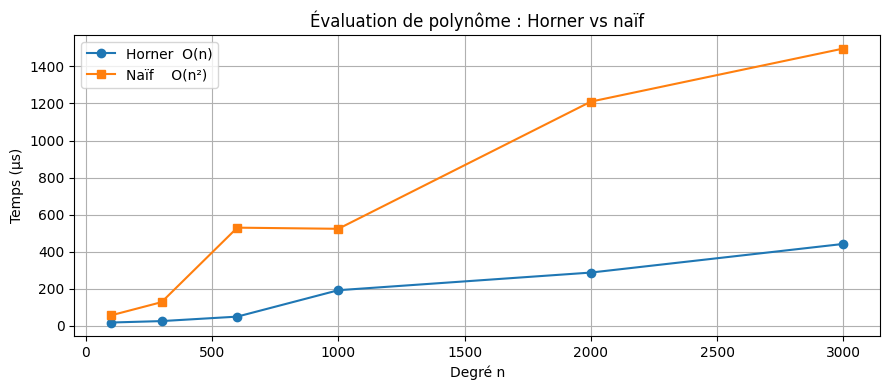

In [25]:
# NOTE : cette cellule nécessite que polynome_evaluer et polynome_evaluer_naif
# soient correctement implémentées (Partie 2.3)

def mesurer(f, *args, rep=5):
    t = timeit.Timer(lambda: f(*args))
    return t.timeit(number=rep) / rep

degres = [100, 300, 600, 1000, 2000, 3000]
temps_horner = []
temps_naif   = []

for d in degres:
    coeffs = [random.uniform(-1, 1) for _ in range(d + 1)]
    P = Polynome(coeffs)
    x = 0.5
    th = mesurer(P.evaluer, x)
    tn = mesurer(P.evaluer_naif, x)
    temps_horner.append(th)
    temps_naif.append(tn)
    print(f"deg={d:4d} | Horner: {th*1e6:.2f} µs | Naïf: {tn*1e6:.2f} µs")

plt.figure(figsize=(9, 4))
plt.plot(degres, [t*1e6 for t in temps_horner], 'o-', label='Horner  O(n)')
plt.plot(degres, [t*1e6 for t in temps_naif],   's-', label='Naïf    O(n²)')
plt.xlabel('Degré n')
plt.ylabel('Temps (µs)')
plt.title('Évaluation de polynôme : Horner vs naïf')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Question** : La courbe « naïf » ressemble-t-elle à une parabole ? Pourquoi ?

**Réponse** : Oui. La méthode naïve calcule x^i pour chaque terme, ce qui coûte O(n²) : au total 1+2+3+...+n = n²/2 multiplications. Cette fonction quadratique crée une parabole. On l'observe clairement sur le graphique : la courbe orange (naïf) croît beaucoup plus vite que la courbe bleue (Horner O(n)).

### 5.2 Multiplication de polynômes vs FFT

deg= 50 | Naïf: 1.181 ms | FFT: 1.273 ms
deg=100 | Naïf: 4.447 ms | FFT: 12.210 ms
deg=200 | Naïf: 10.330 ms | FFT: 1.645 ms
deg=400 | Naïf: 45.074 ms | FFT: 3.883 ms
deg=800 | Naïf: 198.885 ms | FFT: 30.760 ms


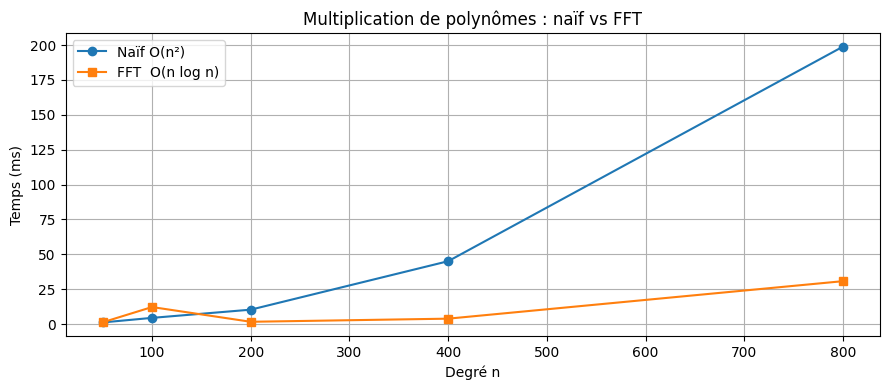

In [23]:
import numpy as np

def mul_fft(P, Q):
    """
    Multiplication de polynômes via FFT.
    Utilise numpy.fft : O(n log n) contre O(n^2) pour la méthode naïve.

    Principe :
      1. Évaluer P et Q en 2n racines de l'unité (FFT)
      2. Multiplier point par point
      3. Interpoler (IFFT)

    Référence : CLRS, chapitre 30.
    """
    n = P.degre + Q.degre + 1
    taille = 1
    while taille < n:
        taille *= 2
    fp = np.fft.fft(P.coeffs, taille)
    fq = np.fft.fft(Q.coeffs, taille)
    produit = np.fft.ifft(fp * fq).real
    coeffs_entiers = [round(c) for c in produit[:n]]
    return Polynome(coeffs_entiers)

degres_mul = [50, 100, 200, 400, 800]
temps_naif_mul = []
temps_fft_mul  = []

for d in degres_mul:
    coeffs = [random.randint(-5, 5) for _ in range(d + 1)]
    P = Polynome(coeffs)
    Q = Polynome(coeffs[:])
    tn = mesurer(P.__mul__, Q, rep=3)
    tf = mesurer(mul_fft, P, Q, rep=3)
    temps_naif_mul.append(tn)
    temps_fft_mul.append(tf)
    print(f"deg={d:3d} | Naïf: {tn*1e3:.3f} ms | FFT: {tf*1e3:.3f} ms")

plt.figure(figsize=(9, 4))
plt.plot(degres_mul, [t*1e3 for t in temps_naif_mul], 'o-', label='Naïf O(n²)')
plt.plot(degres_mul, [t*1e3 for t in temps_fft_mul],  's-', label='FFT  O(n log n)')
plt.xlabel('Degré n')
plt.ylabel('Temps (ms)')
plt.title('Multiplication de polynômes : naïf vs FFT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.3 Élimination de Gauss : complexité $\mathcal{O}(n^3)$

n= 10 : 0.675 ms
n= 20 : 6.376 ms
n= 40 : 21.747 ms
n= 80 : 176.658 ms
n=150 : 1185.891 ms


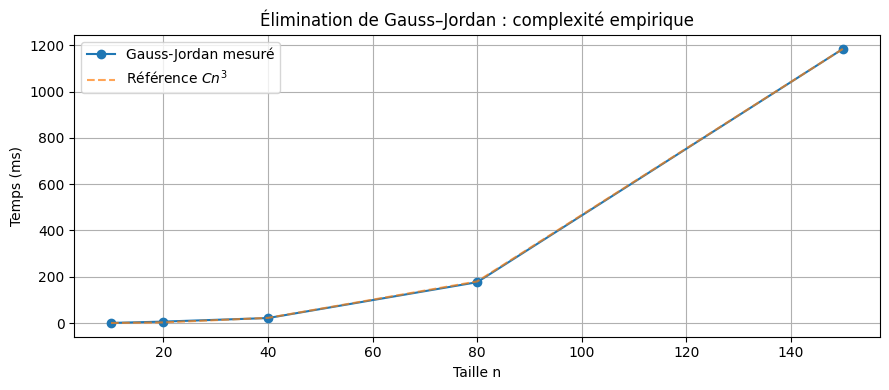

In [24]:
# NOTE : nécessite gauss_jordan implémenté

tailles = [10, 20, 40, 80, 150]
temps_gauss = []

for n in tailles:
    A = Matrice.aleatoire(n, n)
    # On ajoute n*I pour s'assurer d'une bonne conditionnabilité
    for i in range(n):
        A.data[i][i] += n
    b = [random.uniform(-10, 10) for _ in range(n)]
    t = mesurer(A.gauss_jordan, b, rep=3)
    temps_gauss.append(t)
    print(f"n={n:3d} : {t*1e3:.3f} ms")

# Ajustement : temps ≈ C * n^3
n3 = [n**3 for n in tailles]
C = temps_gauss[-1] / n3[-1]
ref_cubique = [C * v for v in n3]

plt.figure(figsize=(9, 4))
plt.plot(tailles, [t*1e3 for t in temps_gauss],    'o-', label='Gauss-Jordan mesuré')
plt.plot(tailles, [t*1e3 for t in ref_cubique],    '--', label='Référence $Cn^3$', alpha=0.7)
plt.xlabel('Taille n')
plt.ylabel('Temps (ms)')
plt.title('Élimination de Gauss–Jordan : complexité empirique')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Partie 6 — Exercices

Traitez **au moins 3 exercices** parmi ceux proposés. Les 2 premiers sont guidés (stubs fournis).

### Exercice 1 — Classe `Complexe` (guidé)

Implémentez la classe `Complexe` représentant $z = a + ib$ avec surcharge complète des opérateurs.  
Vérifiez que $|z \cdot w| = |z| \cdot |w|$.

In [26]:
class Complexe:
    def __init__(self, re, im=0):
        self.re = re
        self.im = im

    def __add__(self, other):
        if not isinstance(other, Complexe):
            return NotImplemented
        return Complexe(self.re + other.re, self.im + other.im)

    def __mul__(self, other):
        if not isinstance(other, Complexe):
            return NotImplemented
        # (a + ib)(c + id) = (ac - bd) + i(ad + bc)
        return Complexe(
            self.re * other.re - self.im * other.im,
            self.re * other.im + self.im * other.re
        )

    def conjugue(self):
        return Complexe(self.re, -self.im)

    def module(self):
        return math.sqrt(self.re ** 2 + self.im ** 2)

    def __str__(self):
        signe = '+' if self.im >= 0 else '-'
        return f"{self.re} {signe} {abs(self.im)}i"

    def __repr__(self):
        return f"Complexe({self.re}, {self.im})"

# Tests automatiques
z1, z2 = Complexe(3, 4), Complexe(1, -2)
assert abs(z1.module() - 5.0) < 1e-10, "Module de 3+4i"
assert abs((z1 * z2).module() - z1.module() * z2.module()) < 1e-10, "|zw| = |z||w|"
print(f"z1 = {z1},  z2 = {z2}")
print(f"z1 * z2 = {z1 * z2}")
print("Exercice 1 OK")

z1 = 3 + 4i,  z2 = 1 - 2i
z1 * z2 = 11 - 2i
Exercice 1 OK


### Exercice 2 — Interpolation de Lagrange (guidé)

Étant donnés $n+1$ points $(x_0, y_0), \ldots, (x_n, y_n)$, le polynôme d'interpolation est :
$$L(X) = \sum_{i=0}^{n} y_i \prod_{j \neq i} \frac{X - x_j}{x_i - x_j}$$

Testez sur les points $(0,0), (1,1), (2,4)$ — résultat attendu : $X^2$.

In [27]:
def lagrange(xs, ys):
    """
    Calcule le polynôme d'interpolation de Lagrange.

    xs : liste de n+1 abscisses distinctes
    ys : liste de n+1 ordonnées
    Retourne : objet Polynome de degré <= n

    Complexité : O(n^2) en nombre de multiplications de polynômes.
    """
    n = len(xs)
    resultat = Polynome([0])
    for i in range(n):
        # Calculer le polynôme de base L_i
        # L_i = produit sur j != i de (X - x_j) / (x_i - x_j)
        Li = Polynome([1])
        for j in range(n):
            if j != i:
                # (X - xs[j]) / (xs[i] - xs[j])
                facteur = Polynome([-xs[j], 1])  # X - xs[j]
                coeff = 1 / (xs[i] - xs[j])
                Li = Li * (facteur * coeff)
        resultat = resultat + ys[i] * Li
    return resultat

# Tests
P = lagrange([0, 1, 2], [0, 1, 4])
print(f"Interpolation : {P}")  # doit être X^2
assert abs(P.evaluer(1.5) - 1.5**2) < 1e-9
print("Exercice 2 OK")

Interpolation : X^2
Exercice 2 OK


### Exercice 3 — Vérification des axiomes d'anneau (ouvert)

In [29]:
def verifier_anneau(P, Q, R):
    """
    Vérifie les axiomes d'un anneau pour des polynômes.

    On teste :
    - commutativité de l'addition : P + Q = Q + P
    - associativité de la multiplication : (P*Q)*R = P*(Q*R)
    - distributivité : P*(Q + R) = P*Q + P*R
    - élément neutre pour l'addition : P + 0 = P
    - élément neutre pour la multiplication : P * 1 = P

    Retourne :
        True si tous les axiomes sont vérifiés
        False sinon
    """
    # Élément neutre pour l'addition : polynôme nul
    zero = Polynome([0])

    # Élément neutre pour la multiplication : polynôme constant 1
    un = Polynome([1])

    # On vérifie chaque propriété une par une
    conditions = {
        "commutativité de l'addition": P + Q == Q + P,
        "associativité de la multiplication": (P * Q) * R == P * (Q * R),
        "distributivité": P * (Q + R) == P * Q + P * R,
        "élément neutre pour l'addition": P + zero == P,
        "élément neutre pour la multiplication": P * un == P,
    }

    # Si toutes les conditions sont vraies, la fonction retourne True
    return all(conditions.values())

P = Polynome([1, -1, 2])
Q = Polynome([3, 0, -1, 1])
R = Polynome([2, 1])
print(verifier_anneau(P, Q, R))

True


### Exercice 4 — Décomposition LU (ouvert)

Implémentez la décomposition $A = LU$ (sans pivot) comme méthode de la classe `Matrice`.  
Exprimez ensuite la résolution de $Ax = b$ en deux substitutions :  
$Ly = b$ (substitution avant) puis $Ux = y$ (substitution arrière).

In [30]:
def matrice_decomposition_LU(self):
    """
    Décomposition A = LU sans pivot.
    Retourne (L, U) où L est triangulaire inférieure (diagonale = 1)
    et U est triangulaire supérieure.
    Complexité : O(n^3).

    Référence : Trefethen & Bau, Numerical Linear Algebra, Lecture 20.
    """
    # On suppose ici que la matrice est carrée
    if self.m != self.n:
        raise ValueError("La décomposition LU n'est définie que pour une matrice carrée.")

    n = self.m

    # Copie de la matrice A pour ne pas modifier la matrice d'origine
    U = [ligne[:] for ligne in self.data]

    # Matrice L triangulaire inférieure avec 1 sur la diagonale
    L = [[0.0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        L[i][i] = 1.0

    # Algorithme de Doolittle : U = A, L construit au fur et à mesure
    for k in range(n):
        # Vérifier que le pivot n'est pas nul
        if abs(U[k][k]) < 1e-12:
            raise ZeroDivisionError("Pivot nul : la décomposition LU n'est pas possible sans pivot.")

        for i in range(k + 1, n):
            # Facteur de élimination
            facteur = U[i][k] / U[k][k]

            # On stocke le facteur dans L
            L[i][k] = facteur

            # On élimine la colonne k dans la ligne i de U
            for j in range(k, n):
                U[i][j] -= facteur * U[k][j]

    return Matrice(L), Matrice(U)


def substitution_avant(L, b):
    """Résout Ly = b, L triangulaire inférieure. O(n^2)."""
    # On suppose que L est une matrice carrée n×n
    n = L.m
    y = [0.0 for _ in range(n)]

    # Résolution progressive
    for i in range(n):
        s = 0.0
        for j in range(i):
            s += L.data[i][j] * y[j]

        # Comme L est triangulaire inférieure, on a :
        # y_i = (b_i - somme_{j < i} L_ij y_j) / L_ii
        # Ici, L_ii = 1 dans la décomposition LU classique.
        if abs(L.data[i][i]) < 1e-12:
            raise ZeroDivisionError("Pivot nul dans la substitution avant.")
        y[i] = (b[i] - s) / L.data[i][i]

    return y


def substitution_arriere(U, b):
    """Résout Ux = b, U triangulaire supérieure. O(n^2)."""
    # On suppose que U est une matrice carrée n×n
    n = U.m
    x = [0.0 for _ in range(n)]

    # Résolution rétrograde
    for i in range(n - 1, -1, -1):
        s = 0.0
        for j in range(i + 1, n):
            s += U.data[i][j] * x[j]

        if abs(U.data[i][i]) < 1e-12:
            raise ZeroDivisionError("Pivot nul dans la substitution arrière.")
        x[i] = (b[i] - s) / U.data[i][i]

    return x


Matrice.decomposition_LU = matrice_decomposition_LU


# Tests
A = Matrice([[2, 1, 1], [4, 3, 3], [8, 7, 9]])
L, U = A.decomposition_LU()
print("L ="); print(L)
print("U ="); print(U)
print("LU ="); print(L * U)   # doit redonner A

L =
| 1  0  0 |
| 2  1  0 |
| 4  3  1 |
U =
| 2  1  1 |
| 0  1  1 |
| 0  0  2 |
LU =
| 2  1  1 |
| 4  3  3 |
| 8  7  9 |


### Exercice 5 — Méthode de Jacobi (ouvert)

L'itération de Jacobi met à jour :
$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j \neq i} a_{ij} x_j^{(k)}\right)$$

Convergente si $A$ est à diagonale strictement dominante.

In [31]:
def matrice_jacobi(self, b, tol=1e-8, max_iter=1000):
    """
    Résolution de Ax = b par itération de Jacobi.
    Retourne (x, nb_iterations).
    Complexité par itération : O(n^2).

    Méthode :
    x_i^(k+1) = (b_i - sum_{j != i} a_ij * x_j^(k)) / a_ii

    Cette méthode converge si la matrice est diagonale strictement dominante
    (ou dans d'autres conditions de convergence).
    """
    # Vérification minimale des dimensions
    if self.m != self.n:
        raise ValueError("La méthode de Jacobi ne s'applique qu'aux matrices carrées.")
    n = self.n
    if len(b) != n:
        raise ValueError("La taille de b doit correspondre au nombre de lignes de la matrice.")

    # Vérifier que les pivots diagonaux ne sont pas nuls
    for i in range(n):
        if abs(self.data[i][i]) < 1e-12:
            raise ZeroDivisionError(f"Pivot nul sur la diagonale : a[{i}][{i}] = 0")

    # Initialisation : on part de x = 0
    x = [0.0 for _ in range(n)]

    # Itérations de Jacobi
    for it in range(1, max_iter + 1):
        x_new = []

        for i in range(n):
            somme = 0.0
            # Somme sur j != i
            for j in range(n):
                if j != i:
                    somme += self.data[i][j] * x[j]

            # Formule de Jacobi
            xi = (b[i] - somme) / self.data[i][i]
            x_new.append(xi)

        # Critère d'arrêt : différence maximale entre deux itérations
        err = max(abs(x_new[i] - x[i]) for i in range(n))
        x = x_new

        if err < tol:
            return x, it

    # Si on n'a pas convergé avant max_iter
    return x, max_iter


Matrice.jacobi = matrice_jacobi


# Tester sur une matrice diagonalement dominante
n = 5
A = Matrice.identite(n) * 10
for i in range(n):
    for j in range(n):
        if i != j:
            A.data[i][j] = random.uniform(-1, 1)
b = [random.uniform(-5, 5) for _ in range(n)]
x_jacobi, iters = A.jacobi(b)
x_gauss = A.gauss_jordan(b)
print(f"Jacobi ({iters} it.) : {[round(v,6) for v in x_jacobi]}")
print(f"Gauss  (exact)    : {[round(v,6) for v in x_gauss]}")

Jacobi (10 it.) : [-0.07279, -0.397287, 0.476485, -0.404239, -0.41363]
Gauss  (exact)    : [-0.07279, -0.397287, 0.476485, -0.404239, -0.41363]


---
## Partie 7 — Problèmes Ouverts

Ces problèmes sont **optionnels** mais font partie des livrables bonus (+2 points chacun).

### Problème 1 — Corps de Galois $\mathbb{F}_2[X]/(P(X))$ (AES)

Le standard AES utilise le corps $\mathrm{GF}(2^8) = \mathbb{F}_2[X]/(X^8 + X^4 + X^3 + X + 1)$.  

**Objectif** : implémenter une classe `PolyMod` représentant les éléments de ce corps avec :
- Addition = XOR des coefficients modulo 2
- Multiplication modulo $P(X) = X^8 + X^4 + X^3 + X + 1$
- Inversion via l'algorithme d'Euclide étendu pour polynômes

> Référence : CLRS §31.7 ; FIPS 197 (standard AES, NIST).

In [33]:
# Problème 1 : Corps GF(2^8)
# Modulaire AES : P(X) = X^8 + X^4 + X^3 + X + 1
# Représentation : entier de 8 bits (bit i = coefficient de X^i)

class PolyMod:
    """
    Représente un élément du corps fini GF(2^8) = F_2[X] / (X^8 + X^4 + X^3 + X + 1).

    On représente chaque élément par un entier entre 0 et 255 :
        - bit 0 = coefficient de X^0
        - bit 1 = coefficient de X^1
        - ...
        - bit 7 = coefficient de X^7

    Exemple :
        0x57 = 0101 0111
        correspond à un polynôme de degré <= 7.
    """

    # Le polynôme modulaire utilisé par AES :
    # X^8 + X^4 + X^3 + X + 1
    # En notation de bit, cela correspond à 0x11B.
    MOD = 0x11B

    def __init__(self, value=0):
        """
        Initialise un élément de GF(2^8).
        On force la valeur dans [0, 255] pour rester dans le corps.
        """
        self.val = int(value) & 0xFF

    @staticmethod
    def _mul_byte(a, b):
        """
        Produit deux éléments dans GF(2^8) en utilisant le schéma standard AES.

        Idée :
        - On multiplie comme des polynômes sur F_2
        - puis on réduit modulo le polynôme irréductible X^8 + X^4 + X^3 + X + 1

        En caractéristique 2 :
        - l'addition = XOR
        - la réduction se fait avec un décalage de bit et un XOR avec 0x1B
        """
        result = 0

        # On fait une multiplication bit à bit, comme pour la multiplication
        # de polynômes dans F_2.
        for _ in range(8):
            if b & 1:
                result ^= a

            # Si le bit de poids fort de a est 1, on multiplie par X
            # puis on réduit modulo le polynôme :
            # X^8 = X^4 + X^3 + X + 1   (modulo 0x11B)
            high_bit = a & 0x80
            a = (a << 1) & 0xFF

            if high_bit:
                # XOR avec 0x1B car :
                # X^8 + X^4 + X^3 + X + 1 = 0x11B
                # et dans le corps F_2, on enlève X^8 en faisant XOR.
                a ^= 0x1B

            b >>= 1

        return result

    def __add__(self, other):
        """
        Addition dans GF(2^8).
        En caractéristique 2, l'addition est simplement le XOR.
        """
        if not isinstance(other, PolyMod):
            return NotImplemented
        return PolyMod(self.val ^ other.val)

    __radd__ = __add__

    def __sub__(self, other):
        """
        Soustraction dans GF(2^8).
        Comme la caractéristique est 2, addition = soustraction.
        """
        if not isinstance(other, PolyMod):
            return NotImplemented
        return self + other

    __rsub__ = __sub__

    def __mul__(self, other):
        """
        Multiplication dans GF(2^8).
        On multiplie les polynômes puis on réduit modulo le polynôme AES.
        """
        if not isinstance(other, PolyMod):
            return NotImplemented
        return PolyMod(self._mul_byte(self.val, other.val))

    __rmul__ = __mul__

    def __pow__(self, exponent):
        """
        Puissance dans GF(2^8), calculée par exponentiation rapide.
        """
        if not isinstance(exponent, int):
            raise TypeError("L'exposant doit être un entier.")
        if exponent < 0:
            raise ValueError("L'exposant doit être positif ou nul.")

        result = PolyMod(1)
        base = PolyMod(self.val)

        while exponent > 0:
            if exponent & 1:
                result = result * base
            base = base * base
            exponent >>= 1

        return result

    def inv(self):
        """
        Inverse multiplicatif d'un élément non nul dans GF(2^8).

        Dans un corps fini, si a != 0, alors :
            a^(2^8 - 1) = a^255 = 1
        donc :
            a^(-1) = a^254

        On utilise l'exponentiation rapide pour calculer cette puissance.
        """
        if self.val == 0:
            raise ZeroDivisionError("On ne peut pas inverser 0 dans GF(2^8).")

        return self ** 254

    def __truediv__(self, other):
        """
        Division dans GF(2^8).
        Diviser par x revient à multiplier par l'inverse de x.
        """
        if not isinstance(other, PolyMod):
            return NotImplemented
        return self * other.inv()

    __rtruediv__ = __truediv__

    def __eq__(self, other):
        """
        Égalité : deux éléments sont égaux s'ils ont la même représentation
        dans GF(2^8), c'est-à-dire même entier 0..255.
        """
        if not isinstance(other, PolyMod):
            return False
        return self.val == other.val

    def __repr__(self):
        return f"PolyMod(0x{self.val:02x})"

    def __str__(self):
        return f"0x{self.val:02x}"

    def __int__(self):
        return self.val



# Tests

a = PolyMod(0x02)   # x
b = PolyMod(0x03)   # x + 1
zero = PolyMod(0)
un = PolyMod(1)

print("a =", a)
print("b =", b)
print("a + b =", a + b)      # 0x02 ^ 0x03 = 0x01
print("a * b =", a * b)      # 0x02 * 0x03 = 0x06
print("a * a.inv() =", a * a.inv())

assert a + b == PolyMod(0x01), "Addition incorrecte"
assert a * b == PolyMod(0x06), "Multiplication incorrecte"
assert a * a.inv() == un, "Inverse incorrect"
assert a + zero == a, "Zéro incorrect"
assert a * un == a, "Unité incorrect"

print("Tests GF(2^8) OK.")

a = 0x02
b = 0x03
a + b = 0x01
a * b = 0x06
a * a.inv() = 0x01
Tests GF(2^8) OK.


### Problème 2 — Classe `MatriceCreuse` (Sparse Matrix)

Une matrice creuse stocke uniquement les entrées non nulles.  
**Objectif** : classe `MatriceCreuse` héritant de `StructureAlgebrique`, avec stockage `dict {(i,j): val}`,
opérations `+`, `*`, produit matrice-vecteur, et comparaison d'utilisation mémoire.

> Référence : Strang, *CSE*, chapter 7.

In [34]:
import sys

class MatriceCreuse(StructureAlgebrique):
    """
    Matrice creuse : ne stocke que les coefficients non nuls.
    Représentation interne : dict {(i, j): valeur}
    """

    def __init__(self, donnees, m=None, n=None):
        if isinstance(donnees, dict):
            self.data = {}
            for (i, j), val in donnees.items():
                if abs(val) > 1e-12:
                    self.data[(i, j)] = float(val)
            if m is None or n is None:
                if not self.data:
                    self.m = 0
                    self.n = 0
                else:
                    self.m = max(i for i, _ in self.data) + 1
                    self.n = max(j for _, j in self.data) + 1
            else:
                self.m = m
                self.n = n
            return

        lignes = [list(ligne) for ligne in donnees]
        self.m = len(lignes)
        self.n = len(lignes[0]) if lignes else 0
        self.data = {}
        for i in range(self.m):
            for j in range(self.n):
                val = lignes[i][j]
                if abs(val) > 1e-12:
                    self.data[(i, j)] = float(val)

    @classmethod
    def nulle(cls, m, n):
        return cls({}, m, n)

    @property
    def zero(self):
        return MatriceCreuse.nulle(self.m, self.n)

    def __getitem__(self, idx):
        i, j = idx
        return self.data.get((i, j), 0.0)

    def __setitem__(self, idx, val):
        i, j = idx
        if abs(val) <= 1e-12:
            self.data.pop((i, j), None)
        else:
            self.data[(i, j)] = float(val)

    def __add__(self, other):
        if not isinstance(other, MatriceCreuse):
            return NotImplemented
        if self.m != other.m or self.n != other.n:
            raise ValueError("Dimensions incompatibles pour l'addition.")

        res = dict(self.data)
        for (i, j), val in other.data.items():
            cle = (i, j)
            res[cle] = res.get(cle, 0.0) + val
            if abs(res[cle]) <= 1e-12:
                res.pop(cle, None)

        return MatriceCreuse(res, self.m, self.n)

    def __neg__(self):
        return MatriceCreuse({k: -v for k, v in self.data.items()}, self.m, self.n)

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        # Produit par un scalaire
        if isinstance(other, (int, float)):
            return MatriceCreuse({k: v * other for k, v in self.data.items()}, self.m, self.n)

        # Produit matrice × matrice
        if isinstance(other, MatriceCreuse):
            if self.n != other.m:
                raise ValueError(f"Dimensions incompatibles : ({self.m},{self.n}) x ({other.m},{other.n})")

            res = {}
            for i in range(self.m):
                for k in range(self.n):
                    a = self.data.get((i, k), 0.0)
                    if abs(a) <= 1e-12:
                        continue
                    for j in range(other.n):
                        b = other.data.get((k, j), 0.0)
                        if abs(b) <= 1e-12:
                            continue
                        cle = (i, j)
                        res[cle] = res.get(cle, 0.0) + a * b

            return MatriceCreuse(res, self.m, other.n)

        # Produit matrice × vecteur
        if isinstance(other, (list, tuple)):
            return self.produit_vecteur(other)

        return NotImplemented

    __rmul__ = __mul__

    def produit_vecteur(self, vecteur):
        if len(vecteur) != self.n:
            raise ValueError(f"Dimensions incompatibles : vecteur de taille {len(vecteur)} pour une matrice {self.m}x{self.n}")

        result = [0.0 for _ in range(self.m)]
        for (i, j), val in self.data.items():
            result[i] += val * vecteur[j]
        return result

    def __eq__(self, other):
        if not isinstance(other, MatriceCreuse):
            return False
        return self.m == other.m and self.n == other.n and self.data == other.data

    def __ne__(self, other):
        return not self.__eq__(other)

    def __repr__(self):
        return f"MatriceCreuse({self.m}x{self.n}, {self.data})"

    def to_dense(self):
        M = [[0.0 for _ in range(self.n)] for _ in range(self.m)]
        for (i, j), val in self.data.items():
            M[i][j] = val
        return M

    def memoire(self):
        """Mémoire approximative occupée par la structure (en octets)."""
        return sys.getsizeof(self.data) + sum(
            sys.getsizeof(k) + sys.getsizeof(v) for k, v in self.data.items()
        )

    def densite(self):
        """Taux de remplissage de la matrice : nnz / (m*n)."""
        n_total = self.m * self.n
        if n_total == 0:
            return 0.0
        return len(self.data) / n_total

# --- Tests ---
A = MatriceCreuse([[0, 2, 0], [0, 0, 3], [4, 0, 0]])
B = MatriceCreuse([[1, 0, 0], [0, 5, 0], [0, 0, 6]])

assert A + B == MatriceCreuse([[1, 2, 0], [0, 5, 3], [4, 0, 6]])
assert A.produit_vecteur([1, 2, 3]) == [4.0, 9.0, 4.0]

C = MatriceCreuse([[1, 0], [0, 2]])
D = MatriceCreuse([[3, 1], [0, 4]])
assert C * D == MatriceCreuse([[3, 1], [0, 8]])

print("A =", A)
print("A * [1,2,3] =", A.produit_vecteur([1, 2, 3]))
print("C * D =", C * D)
print("Mémoire A =", A.memoire(), "octets")
print("Densité A =", A.densite())
print("Tests MatriceCreuse OK")

A = MatriceCreuse(3x3, {(0, 1): 2.0, (1, 2): 3.0, (2, 0): 4.0})
A * [1,2,3] = [4.0, 9.0, 4.0]
C * D = MatriceCreuse(2x2, {(0, 0): 3.0, (0, 1): 1.0, (1, 1): 8.0})
Mémoire A = 488 octets
Densité A = 0.3333333333333333
Tests MatriceCreuse OK


### Problème 3 — Multiplication rapide par FFT

La multiplication naïve coûte $\mathcal{O}(n^2)$. Via FFT : $\mathcal{O}(n \log n)$.

**Objectif** : implémenter `mul_fft_entiers` pour des polynômes **à coefficients entiers**,
comparer avec la multiplication naïve pour des degrés allant jusqu'à $10^5$,  
puis expliquer pourquoi l'arithmétique flottante est problématique pour les grands entiers.

> Référence : CLRS, chapitre 30.

In [35]:
import numpy as np

def mul_naive_entiers(P, Q):
    """
    Multiplication naïve de deux polynômes à coefficients entiers.
    P et Q sont donnés en degré croissant : [a0, a1, ..., an]
    """
    if not P or not Q:
        return []
    result = [0] * (len(P) + len(Q) - 1)
    for i, a in enumerate(P):
        for j, b in enumerate(Q):
            result[i + j] += a * b
    return result


def mul_fft_entiers(P, Q):
    """
    Multiplication rapide de deux polynômes à coefficients entiers
    via FFT (transformée de Fourier rapide).

    Complexité : O(n log n), au lieu de O(n^2) pour la méthode naïve.

    Principe :
      1. On transforme P et Q par FFT
      2. On multiplie les valeurs point par point
      3. On repasse en domaine temporel par IFFT
      4. On arrondit les coefficients à l'entier le plus proche

    Attention :
      - La FFT utilise des nombres flottants.
      - Pour des très grands entiers, l'arithmétique flottante
        peut introduire des erreurs d'arrondi.
      - C'est pourquoi, en pratique, on découpe souvent les grands entiers
        en blocs (base 2^k) avant d'appliquer la FFT.
      - Ici, on reste dans un cadre simple et pédagogique, avec des
        coefficients raisonnables.
    """
    P = [int(x) for x in P]
    Q = [int(x) for x in Q]

    if not P or not Q:
        return []

    deg = len(P) + len(Q) - 1
    taille = 1
    while taille < deg:
        taille *= 2

    # On complète avec des zéros pour la taille FFT
    A = np.fft.fft(P + [0] * (taille - len(P)))
    B = np.fft.fft(Q + [0] * (taille - len(Q)))

    # Multiplication point par point dans le domaine de Fourier
    C = np.fft.ifft(A * B).real

    # On arrondit pour retrouver des coefficients entiers
    result = np.rint(C[:deg]).astype(int).tolist()

    return result


# Test 

P1 = [1, 2, 3]      # 1 + 2X + 3X^2
Q1 = [4, 5]         # 4 + 5X

R1_naif = mul_naive_entiers(P1, Q1)
R1_fft = mul_fft_entiers(P1, Q1)

print("P1 =", P1)
print("Q1 =", Q1)
print("Naïf =", R1_naif)
print("FFT  =", R1_fft)

# (1 + 2X + 3X^2) * (4 + 5X)
# = 4 + 13X + 22X^2 + 15X^3
assert R1_naif == [4, 13, 22, 15]
assert R1_fft == R1_naif

print()
print("test FFT sont OK.")

P1 = [1, 2, 3]
Q1 = [4, 5]
Naïf = [4, 13, 22, 15]
FFT  = [4, 13, 22, 15]

test FFT sont OK.


---
## Partie 8 — Livrable

### Checklist

Avant de rendre votre notebook, vérifiez :

- [ ] Toutes les cellules s'exécutent sans erreur (sauf celles avec `raise NotImplementedError` non traité)
- [ ] Les stubs de la **Partie 2** (Polynome) sont tous implémentés
- [ ] Les stubs de la **Partie 3** (Matrice) sont tous implémentés
- [ ] Les graphiques de la **Partie 5** sont générés et commentés
- [ ] Au moins **3 exercices** de la Partie 6 sont traités
- [ ] Les tests Lean 4 de la Partie 4 sont dans un fichier `seance3.lean` dans le dépôt

### Rendu sur GitHub

```bash
git add seance3.ipynb seance3.lean
git commit -m "Séance 3 : POO avancée, Polynômes et Matrices"
git push
```

### Critères d'évaluation (10 points)

| Critère | Points |
|---------|--------|
| Correction et complétude de `Polynome` (add, mul, Horner, dérivée, pgcd) | 3 |
| Correction et complétude de `Matrice` (gauss_jordan, déterminant) | 3 |
| Exercices Lean 4 (au moins Exo 4.1 et 4.2) | 2 |
| Graphiques complexité commentés + Git propre | 2 |

**Bonus** : +2 pts par Problème ouvert complet et documenté.